# Fixing levels

In [1]:
# %% Libraries
import os
import scanpy as sc
from pathlib import Path

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% object versions
COMB_V= 'clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

In [2]:
# load comb obj
comb = sc.read_h5ad(COMB_PATH)

## Level 3

In [5]:
leiden_resolvi_map = {
    # epithelial
    "7": "BC",
    "15": "SC",
    "12": "MCC",
    "21": "Gob",
    "19": "AT1",
    "13": "AT2",

    # Lymphoid
    "4": "T",
    "1": "B",
    "9": "PC_IgA", # plasma IGHA1
    "17": "PC_IgA", # plasma IGHA1
    "11": "PC_IgM", # plasma IGHM
    "20": "PC_IgG", # plasma IGHG1/2
    "16": "PC_IgG", # plasma IGHG1/2
    "22": "PC_IgAG", # plasma mixed cluster

    # Myeloid
    "3": "Neut",
    "5": "Mast",
    "18": "AlvMac",
    "8": "Mac",

    # Stroma
    "6": "Fib",
    "14": "actFib", # POSTN activated 
    "2": "SMC", # smooth muscle cells

    # Endothelial
    "10": "EC",

    # ambiguous
    "0": "Amb",
    "23": "Amb",
}

RESOLVI_CT_KEY = 'ct_resolvi'
RESOLVI_CLUSTERS_KEY = 'leiden_resolvi_1.0'
comb.obs['ct_resolvi'] = comb.obs[RESOLVI_CLUSTERS_KEY].map(leiden_resolvi_map).astype('category')


# ANN LVL 3
comb.obs['ann_lvl_3'] = comb.obs['ct_resolvi']

## Check in UMAP

[<Axes: title={'center': 'leiden_resolvi_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'ann_lvl_3'}, xlabel='UMAP1', ylabel='UMAP2'>]

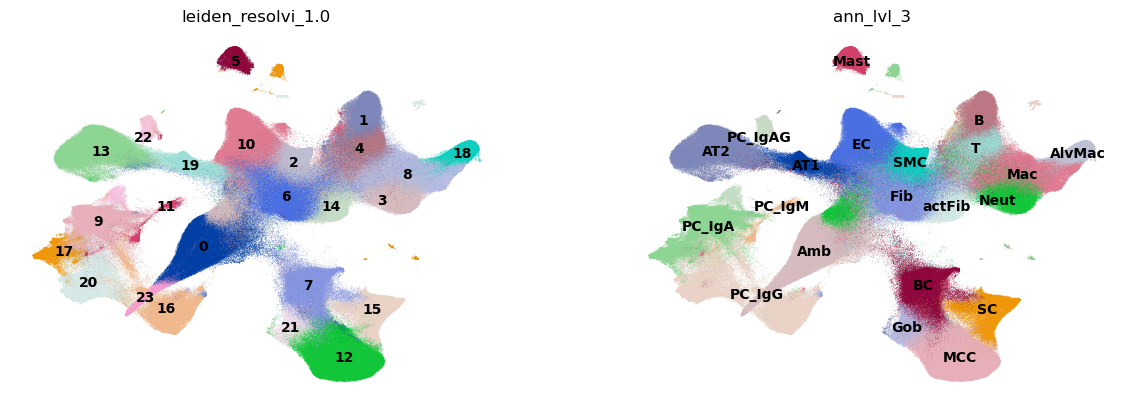

In [9]:
sc.pl.umap(
    comb,
    color=[RESOLVI_CLUSTERS_KEY, 'ann_lvl_3'],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = False,
    show=False,
    ncols=2
)

In [7]:
comb.obs

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,...,leiden_resolvi_0.8,leiden_resolvi_0.9,leiden_resolvi_1.0,leiden_resolvi_1.1,leiden_resolvi_1.2,leiden_resolvi_1.3,leiden_resolvi_1.4,leiden_resolvi_1.5,ct_resolvi,ann_lvl_3
cell_id,,,,,,,,,,,,,,,,,,,,,
SLIDE04_0,0,c_4_148_1200,389.99450,2561.8610,0.578297,6,45.50,296.0,1.0,SLIDE04,...,7,14,9,14,12,1,0,12,PC_IgA,PC_IgA
SLIDE04_2,2,c_4_160_1452,937.05630,2050.9023,0.365066,4,37.75,244.0,1.0,SLIDE04,...,6,8,6,7,8,5,21,6,Fib,Fib
SLIDE04_3,3,c_4_160_1451,1022.33000,2049.8896,0.447500,7,25.00,206.0,1.0,SLIDE04,...,0,4,3,2,0,4,4,2,Neut,Neut
SLIDE04_4,4,c_4_160_1324,726.74194,2110.9038,0.526499,7,116.75,474.0,1.0,SLIDE04,...,8,10,4,4,9,9,3,4,T,T
SLIDE04_5,5,c_4_160_1346,750.20110,2100.1968,0.524456,0,92.00,442.0,1.0,SLIDE04,...,6,8,6,7,8,5,5,10,Fib,Fib
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLIDE02_426982,426982,c_2_113_381,11781.21800,13423.0800,0.815171,7,29.25,166.0,1.0,SLIDE02,...,9,21,10,5,18,5,21,22,EC,EC
SLIDE02_426983,426983,c_2_113_366,11778.81100,13431.9150,0.765805,3,21.75,158.0,1.0,SLIDE02,...,9,6,10,5,5,8,9,11,EC,EC
SLIDE02_426985,426985,c_2_113_317,11782.32000,13455.4850,0.865000,3,12.50,92.0,1.0,SLIDE02,...,1,1,0,1,4,4,4,3,Amb,Amb


## Save annotations

In [8]:
# %% Save object
comb.write_h5ad(COMB_PATH)